# Best Completed Run and Confusion Matrix

This notebook reads the completed segmented6 hybrid results, selects the best run from the current seed-metrics CSV, and shows its confusion matrix.

It does not start training or modify existing outputs.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except Exception:
    SEABORN_AVAILABLE = False

import mobilenetv3small_segmented6_hybrid_lib as segmented6_lib

SEGMENTED6_ROOT = Path(r"E:\Thesis Code\training_outputs\mobilenetv3small_segmented6_hybrid")
SEGMENTED6_SEED_METRICS_PATH = SEGMENTED6_ROOT / "segmented6_hybrid_seed_metrics.csv"
SEGMENTED6_FIGURES_ROOT = SEGMENTED6_ROOT / "figures"
LABEL_ORDER = list(segmented6_lib.LABEL_ORDER)

print("Seed metrics path:", SEGMENTED6_SEED_METRICS_PATH)
print("Figures root:", SEGMENTED6_FIGURES_ROOT)
print("Label order:", LABEL_ORDER)

[INFO] TensorFlow XLA/JIT disabled.
Seed metrics path: E:\Thesis Code\training_outputs\mobilenetv3small_segmented6_hybrid\segmented6_hybrid_seed_metrics.csv
Figures root: E:\Thesis Code\training_outputs\mobilenetv3small_segmented6_hybrid\figures
Label order: ['fresh', 'not fresh', 'spoiled']


In [4]:
if not SEGMENTED6_SEED_METRICS_PATH.exists():
    raise FileNotFoundError(f"Missing metrics CSV: {SEGMENTED6_SEED_METRICS_PATH}")

seed_metrics_df = pd.read_csv(SEGMENTED6_SEED_METRICS_PATH)
print("Completed runs:", len(seed_metrics_df))

ranked_df = seed_metrics_df.sort_values(
    ["macro_f1", "accuracy", "adjacent_accuracy", "top_2_accuracy"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

display(
    ranked_df[
        [
            "fold_name",
            "seed",
            "held_out_sample",
            "accuracy",
            "macro_f1",
            "top_2_accuracy",
            "adjacent_accuracy",
            "severe_error_rate",
        ]
    ].head(18)
)

best_row = ranked_df.iloc[0]
print("Best run by macro F1:")
print(
    best_row[
        [
            "fold_name",
            "seed",
            "held_out_sample",
            "accuracy",
            "macro_f1",
            "top_2_accuracy",
            "adjacent_accuracy",
            "severe_error_rate",
            "model_path",
            "predictions_path",
        ]
    ]
)

Completed runs: 18


,fold_name,seed,held_out_sample,accuracy,macro_f1,top_2_accuracy,adjacent_accuracy,severe_error_rate
0,fold5,42,pork_ham_sample_5,0.686667,0.643291,0.990000,0.940000,0.060000
1,fold4,42,pork_belly_sample_4,0.603636,0.607670,0.947273,0.981818,0.018182
2,fold4,2026,pork_belly_sample_4,0.576364,0.546136,0.925455,0.969091,0.030909
3,fold5,2026,pork_ham_sample_5,0.631667,0.545543,0.980000,0.935000,0.065000
4,fold5,123,pork_ham_sample_5,0.593333,0.540416,0.971667,0.871667,0.128333
5,fold3,2026,pork_belly_sample_3,0.540541,0.525904,0.955598,0.971042,0.028958
6,fold6,2026,pork_ham_sample_6,0.625000,0.519299,0.831667,0.998333,0.001667
7,fold6,42,pork_ham_sample_6,0.586667,0.492725,0.898333,0.998333,0.001667
8,fold4,123,pork_belly_sample_4,0.536364,0.486109,0.938182,0.952727,0.047273
9,fold3,42,pork_belly_sample_3,0.527027,0.461211,0.859073,0.994208,0.005792


Best run by macro F1:
fold_name                                                        fold5
seed                                                                42
held_out_sample                                      pork_ham_sample_5
accuracy                                                      0.686667
macro_f1                                                      0.643291
top_2_accuracy                                                    0.99
adjacent_accuracy                                                 0.94
severe_error_rate                                                 0.06
model_path           e:\Thesis Code\training_outputs\mobilenetv3sma...
predictions_path     e:\Thesis Code\training_outputs\mobilenetv3sma...
Name: 0, dtype: object


In [6]:
best_run_stem = str(best_row["run_stem"])
best_confusion_png = SEGMENTED6_FIGURES_ROOT / f"{best_run_stem}_confusion_matrix.png"
best_confusion_norm_png = SEGMENTED6_FIGURES_ROOT / f"{best_run_stem}_normalized_confusion_matrix.png"

cm = np.array(json.loads(best_row["confusion_matrix_json"]))
cm_norm = np.array(json.loads(best_row["normalized_confusion_matrix_json"]))

print("Best run stem:", best_run_stem)
print("Saved confusion matrix image:", best_confusion_png)
print("Saved normalized confusion matrix image:", best_confusion_norm_png)

print("Raw confusion matrix:")
print(cm)
print("Normalized confusion matrix:")
print(cm_norm)

Best run stem: segmented6_hybrid_fold5_seed42
Saved confusion matrix image: E:\Thesis Code\training_outputs\mobilenetv3small_segmented6_hybrid\figures\segmented6_hybrid_fold5_seed42_confusion_matrix.png
Saved normalized confusion matrix image: E:\Thesis Code\training_outputs\mobilenetv3small_segmented6_hybrid\figures\segmented6_hybrid_fold5_seed42_normalized_confusion_matrix.png
Raw confusion matrix:
[[194   4   2]
 [ 71  52  77]
 [ 34   0 166]]
Normalized confusion matrix:
[[0.97  0.02  0.01 ]
 [0.355 0.26  0.385]
 [0.17  0.    0.83 ]]


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

if SEABORN_AVAILABLE:
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        ax=axes[0],
    )
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".3f",
        cmap="Greens",
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        ax=axes[1],
    )
else:
    axes[0].imshow(cm, cmap="Blues")
    axes[1].imshow(cm_norm, cmap="Greens")
    for ax, mat, fmt in [(axes[0], cm, "d"), (axes[1], cm_norm, ".3f")]:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center", color="black")
        ax.set_xticks(range(len(LABEL_ORDER)))
        ax.set_yticks(range(len(LABEL_ORDER)))
        ax.set_xticklabels(LABEL_ORDER)
        ax.set_yticklabels(LABEL_ORDER)

axes[0].set_title(f"Best Run Confusion Matrix\n{best_run_stem}")
axes[1].set_title(f"Best Run Normalized Confusion Matrix\n{best_run_stem}")
for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

Saved confusion matrix PNG:


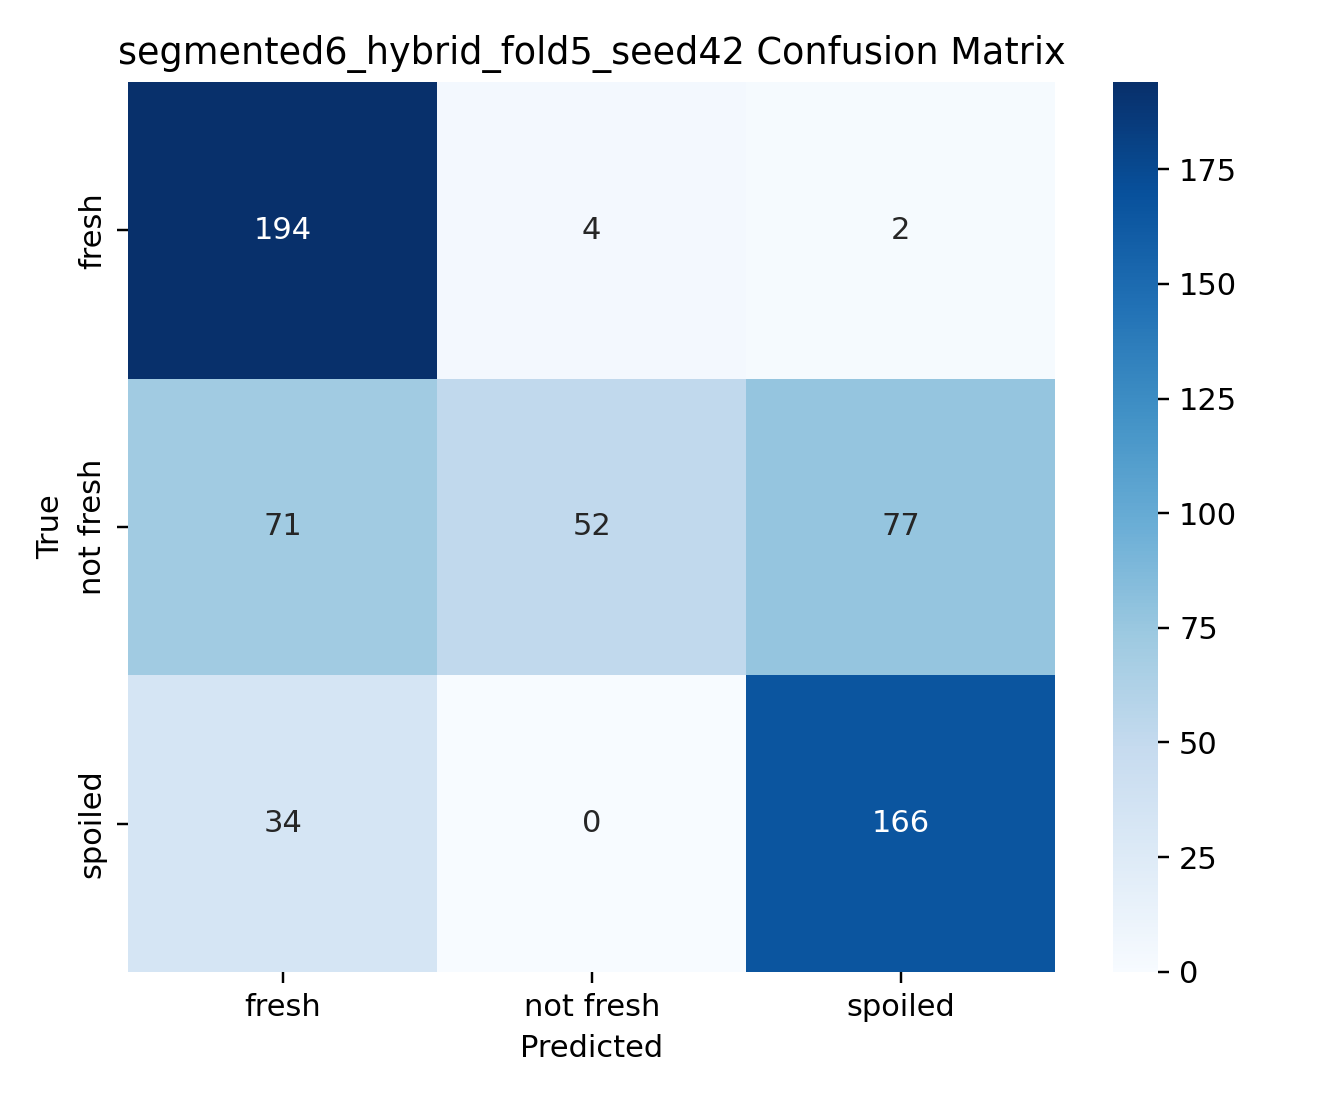

Saved normalized confusion matrix PNG:


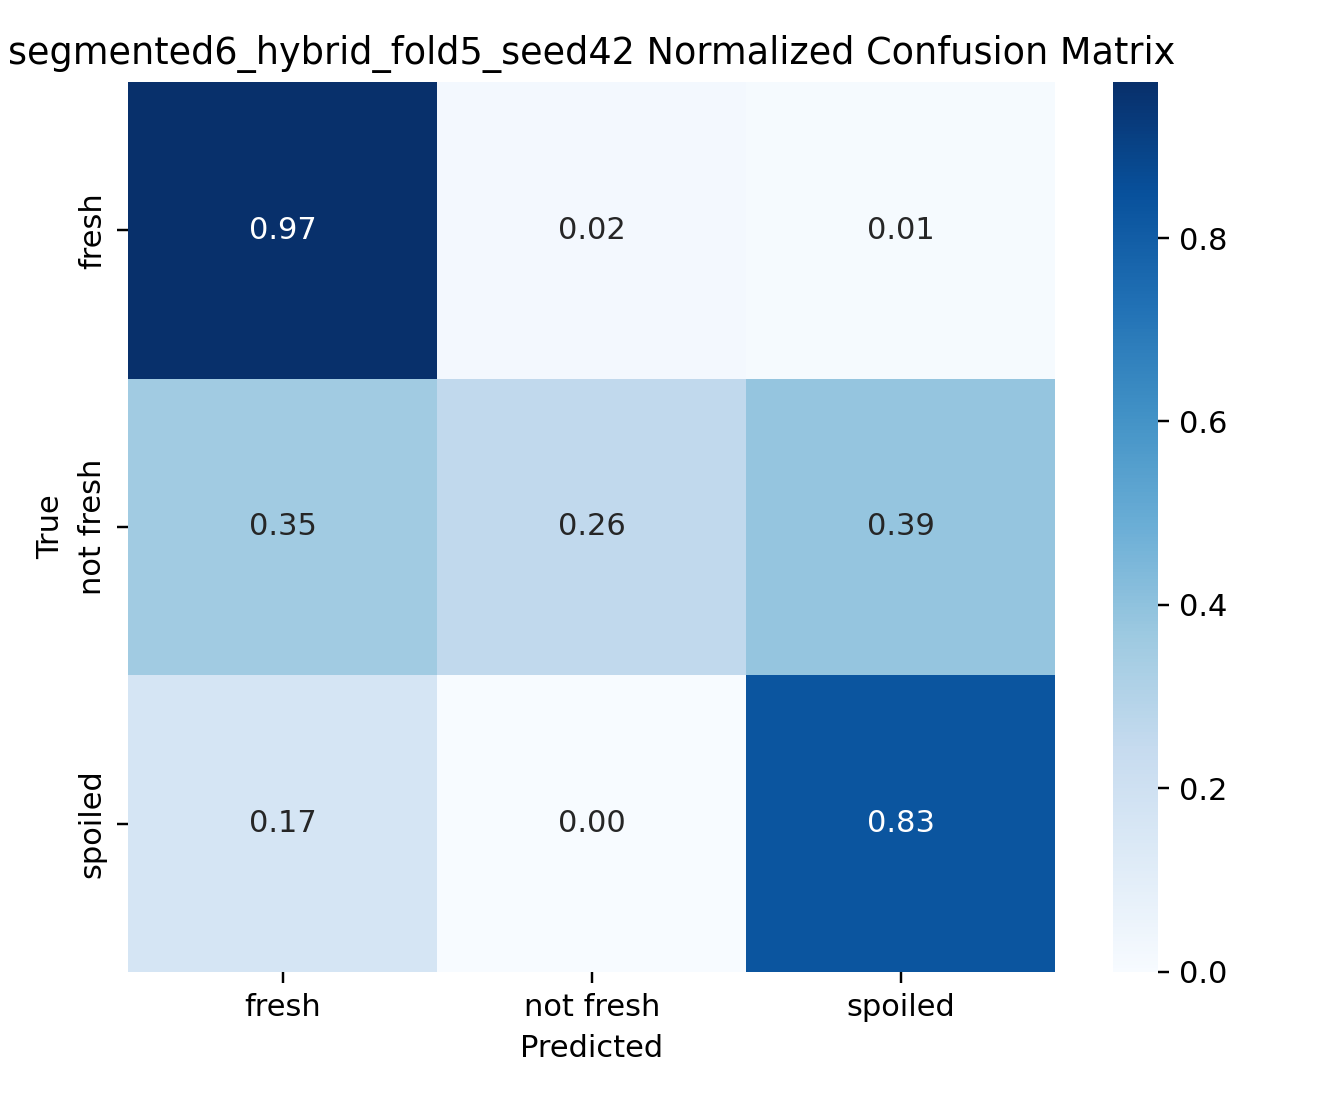

In [8]:
if best_confusion_png.exists():
    print("Saved confusion matrix PNG:")
    display(Image(filename=str(best_confusion_png)))
else:
    print("Saved confusion matrix PNG not found:", best_confusion_png)

if best_confusion_norm_png.exists():
    print("Saved normalized confusion matrix PNG:")
    display(Image(filename=str(best_confusion_norm_png)))
else:
    print("Saved normalized confusion matrix PNG not found:", best_confusion_norm_png)